# 1.3 Exploratory data analysis

(1) Load preprocessed train, (2) check its structure, (3) explore `price` vs the other columns.

| Artifact | Path |
|---|---|
| Input | `1-experimentation/data/data_preprocessed_train.csv` |


In [1]:
%pip install -q pandas matplotlib seaborn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid")

TARGET = "price"
CONDITION_ORDER = ["Poor", "Fair", "Good", "Excellent"]
PREPROCESSED_TRAIN_PATH = "../data/data_preprocessed_train.csv"


## 1. Load preprocessed train

In [3]:
train_df = pd.read_csv(PREPROCESSED_TRAIN_PATH)

print(f"Rows: {train_df.shape[0]} | Columns: {train_df.shape[1]}")
train_df.head()


Rows: 67 | Columns: 7


,price,sqft,bedrooms,bathrooms,location,year_built,condition
0,495000.0,1950.0,3.0,2.0,Urban,1981.0,Good
1,320000.0,1700.0,2.0,1.5,Rural,1961.0,Fair
2,615000.0,2230.0,3.0,2.0,Downtown,1986.0,Good
3,398000.0,1680.0,2.0,2.0,Suburb,1968.0,Fair
4,357000.0,1580.0,2.0,1.5,Suburb,1960.0,Fair


## 2. Structural profile

In [4]:
train_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67 entries, 0 to 66
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   price       67 non-null     float64
 1   sqft        67 non-null     float64
 2   bedrooms    67 non-null     float64
 3   bathrooms   67 non-null     float64
 4   location    67 non-null     object 
 5   year_built  67 non-null     float64
 6   condition   67 non-null     object 
dtypes: float64(5), object(2)
memory usage: 3.8+ KB


## 3. Explore the target

In [5]:
numeric_cols = train_df.select_dtypes(include="number").columns.tolist()
train_df[numeric_cols].corr(numeric_only=True)[TARGET].sort_values(ascending=False).to_frame("corr_with_price")


,corr_with_price
price,1.000000
sqft,0.980876
bathrooms,0.961744
bedrooms,0.927138
year_built,0.879035


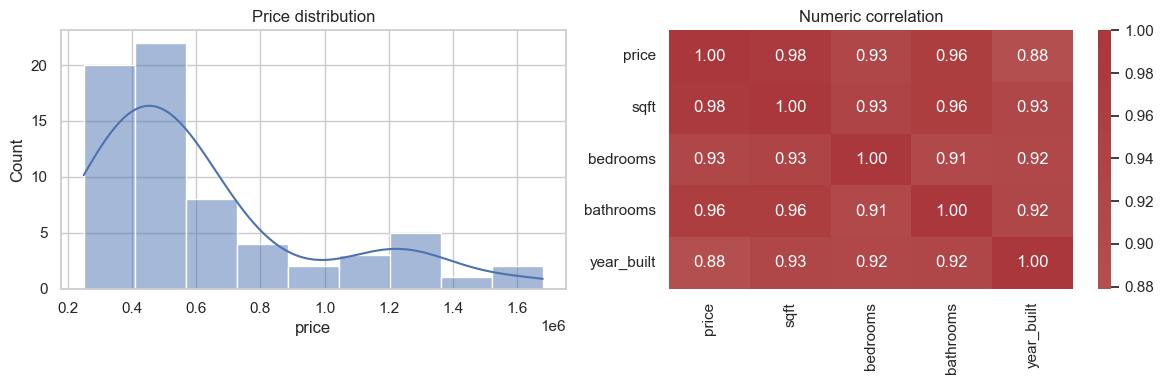

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train_df[TARGET], kde=True, ax=axes[0])
axes[0].set_title("Price distribution")
sns.heatmap(
    train_df[numeric_cols].corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    ax=axes[1],
)
axes[1].set_title("Numeric correlation")
fig.tight_layout()
plt.show()


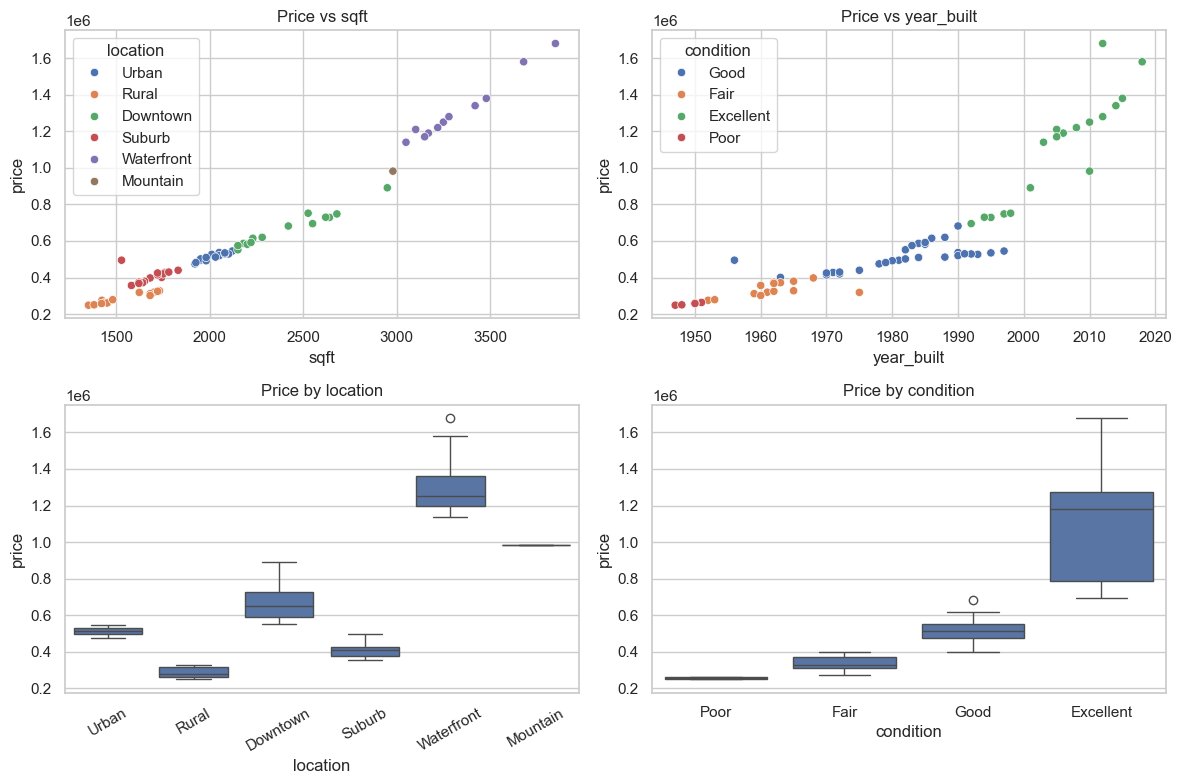

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.scatterplot(data=train_df, x="sqft", y=TARGET, hue="location", ax=axes[0, 0])
axes[0, 0].set_title("Price vs sqft")

sns.scatterplot(data=train_df, x="year_built", y=TARGET, hue="condition", ax=axes[0, 1])
axes[0, 1].set_title("Price vs year_built")

sns.boxplot(data=train_df, x="location", y=TARGET, ax=axes[1, 0])
axes[1, 0].tick_params(axis="x", rotation=30)
axes[1, 0].set_title("Price by location")

sns.boxplot(data=train_df, x="condition", y=TARGET, order=CONDITION_ORDER, ax=axes[1, 1])
axes[1, 1].set_title("Price by condition")

fig.tight_layout()
plt.show()
